In [2]:
import pandas as pd

# Keep_default_na=False and na_values=[''] to prevent pd from misinterpreting values (e.g. NA and 'None')
df = pd.read_csv('final_dataset.csv', keep_default_na=False, na_values=[''])

# Checking data types and non-null counts per column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 53817 entries, 0 to 53816
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   REF_AREA              53817 non-null  int64  
 1   TIME_PERIOD           53817 non-null  int64  
 2   MUNICIPALITY          53817 non-null  str    
 3   PROVINCE_CODE         53817 non-null  str    
 4   PROVINCE_NAME         53817 non-null  str    
 5   SURFACE_KMQ           53817 non-null  float64
 6   SURFACE_YEAR          53817 non-null  int64  
 7   POPULATION            53817 non-null  int64  
 8   POPULATION_YEAR       53817 non-null  int64  
 9   INJURED               53817 non-null  int64  
 10  KILLED                53817 non-null  int64  
 11  TOTAL_ACCIDENTS       53817 non-null  int64  
 12  ACCIDENTS_PER_CAPITA  53817 non-null  float64
 13  ACCIDENTS_PER_KMQ     53817 non-null  float64
dtypes: float64(3), int64(8), str(3)
memory usage: 5.7 MB


In [3]:
# Checking basic statistics on the derived metrics columns to identify outliers
df[['ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']].describe()

,ACCIDENTS_PER_CAPITA,ACCIDENTS_PER_KMQ
count,53817.000000,53817.000000
mean,17.654290,0.617001
std,19.016195,1.607034
min,0.000000,0.000000
25%,5.420054,0.029524
50%,14.362313,0.149447
75%,24.673671,0.517810
max,851.063830,46.912592


In [ ]:
# Showing the single highest value for each derived metric to investigate the extreme values seen in describe()
print(df[df['ACCIDENTS_PER_CAPITA'] == df['ACCIDENTS_PER_CAPITA'].max()][
    ['MUNICIPALITY', 'TIME_PERIOD', 'POPULATION', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_CAPITA']])
print(df[df['ACCIDENTS_PER_KMQ'] == df['ACCIDENTS_PER_KMQ'].max()][
    ['MUNICIPALITY', 'TIME_PERIOD', 'SURFACE_KMQ', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_KMQ']])


     MUNICIPALITY  TIME_PERIOD  POPULATION  TOTAL_ACCIDENTS  \
1038   Moncenisio         2022          47                4   

      ACCIDENTS_PER_CAPITA  
1038             851.06383  
      MUNICIPALITY  TIME_PERIOD  SURFACE_KMQ  TOTAL_ACCIDENTS  \
11931       Milano         2018     181.6783             8523   

       ACCIDENTS_PER_KMQ  
11931          46.912592  


In [ ]:
# Top 10 rows by ACCIDENTS_PER_CAPITA
df.sort_values('ACCIDENTS_PER_CAPITA', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'POPULATION', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_CAPITA']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,POPULATION,TOTAL_ACCIDENTS,ACCIDENTS_PER_CAPITA
1038,Moncenisio,Torino,2022,47,4,851.063830
18916,Castel Condino,Trento,2019,224,11,491.071429
18359,Ponte Gardena/Waidbruck,Bolzano/Bozen,2018,195,8,410.256410
18915,Castel Condino,Trento,2018,222,9,405.405405
3290,Argentera,Cuneo,2024,77,3,389.610390
6937,Bard,Valle d'Aosta/Vallée d'Aoste,2019,122,4,327.868852
50498,Morterone,Lecco,2023,33,1,303.030303
1034,Moncenisio,Torino,2018,33,1,303.030303
6941,Bard,Valle d'Aosta/Vallée d'Aoste,2023,102,3,294.117647
50079,Villanova Biellese,Biella,2023,175,5,285.714286


In [ ]:
# Top 10 rows by ACCIDENTS_PER_KMQ
df.sort_values('ACCIDENTS_PER_KMQ', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'SURFACE_KMQ', 'TOTAL_ACCIDENTS', 'ACCIDENTS_PER_KMQ']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,SURFACE_KMQ,TOTAL_ACCIDENTS,ACCIDENTS_PER_KMQ
11931,Milano,Milano,2018,181.6783,8523,46.912592
11932,Milano,Milano,2019,181.6783,8263,45.481491
11936,Milano,Milano,2023,181.8450,7812,42.959663
11935,Milano,Milano,2022,181.8450,7783,42.800187
11937,Milano,Milano,2024,181.8450,7743,42.580219
11934,Milano,Milano,2021,181.8450,7465,41.051445
11734,Cormano,Milano,2024,4.4733,126,28.167125
11698,Cinisello Balsamo,Milano,2023,12.7240,353,27.742848
12214,Sesto San Giovanni,Milano,2022,11.6989,323,27.609433
11699,Cinisello Balsamo,Milano,2024,12.7240,348,27.349890


In [7]:
# Capping outliers above Q3 + 1.5*IQR for each column, keeping originals for reference and further analysis
columns_to_check = ['TOTAL_ACCIDENTS', 'ACCIDENTS_PER_CAPITA', 'ACCIDENTS_PER_KMQ']

for column_name in columns_to_check:
    q1 = df[column_name].quantile(0.25)
    q3 = df[column_name].quantile(0.75)
    iqr = q3 - q1
    upper_bound = q3 + 1.5 * iqr

    capped_column_name = 'CAPPED_' + column_name
    df[capped_column_name] = df[column_name].clip(upper=upper_bound)

    outlier_count = (df[column_name] > upper_bound).sum()
    outlier_percentage = round(outlier_count / df[column_name].count() * 100, 2)
    print(column_name, '- outliers:', outlier_count, '(', outlier_percentage, '%)')


TOTAL_ACCIDENTS - outliers: 6616 ( 12.29 %)
ACCIDENTS_PER_CAPITA - outliers: 1874 ( 3.48 %)
ACCIDENTS_PER_KMQ - outliers: 6354 ( 11.81 %)


In [8]:
# Grouping population into ranges
bins = [0, 500, 1000, 2000, 5000, 10000, df['POPULATION'].max()]
df['POPULATION_RANGE'] = pd.cut(df['POPULATION'], bins=bins)

# Checking how ACCIDENTS_PER_CAPITA behaves within each range in order to find a population threshold
df.groupby('POPULATION_RANGE')['ACCIDENTS_PER_CAPITA'].agg(['mean', 'std', 'max', 'count'])

,mean,std,max,count
POPULATION_RANGE,,,,
"(0, 500]",18.105770,38.598317,851.063830,5651
"(500, 1000]",15.328901,20.452243,211.946050,7280
"(1000, 2000]",15.101189,16.393715,160.183066,10324
"(2000, 5000]",15.914019,12.441009,127.886323,13913
"(5000, 10000]",18.502176,12.263809,151.877373,8212
"(10000, 2820219]",24.527025,12.324945,86.816720,8437


In [9]:
# Marking municipalities with population below 1000, where ACCIDENTS_PER_CAPITA was shown to be statistically unstable
population_threshold = 1000
df['SMALL_MUNICIPALITY'] = df['POPULATION'] < population_threshold
print('Total number small municipality:', df['SMALL_MUNICIPALITY'].sum())

Total number small municipality: 12914


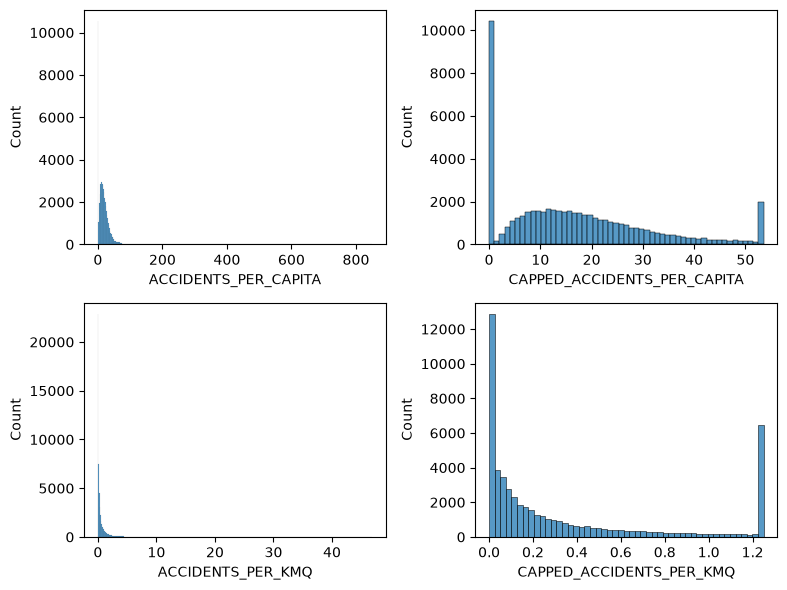

In [10]:
import seaborn as sns
import matplotlib.pyplot as plt


# Comparing original vs capped distributions for the two derived metrics 
figure, axes = plt.subplots(2, 2, figsize=(8, 6))

sns.histplot(df['ACCIDENTS_PER_CAPITA'], ax=axes[0, 0])
axes[0, 0].set_xlabel('ACCIDENTS_PER_CAPITA')

sns.histplot(df['CAPPED_ACCIDENTS_PER_CAPITA'], ax=axes[0, 1])
axes[0, 1].set_xlabel('CAPPED_ACCIDENTS_PER_CAPITA')

sns.histplot(df['ACCIDENTS_PER_KMQ'], ax=axes[1, 0])
axes[1, 0].set_xlabel('ACCIDENTS_PER_KMQ')

sns.histplot(df['CAPPED_ACCIDENTS_PER_KMQ'], ax=axes[1, 1])
axes[1, 1].set_xlabel('CAPPED_ACCIDENTS_PER_KMQ')

plt.tight_layout()
plt.show()

# NOTE: the tall bars in the capped columns plots show all the outliers above the threshold are forced to the same value

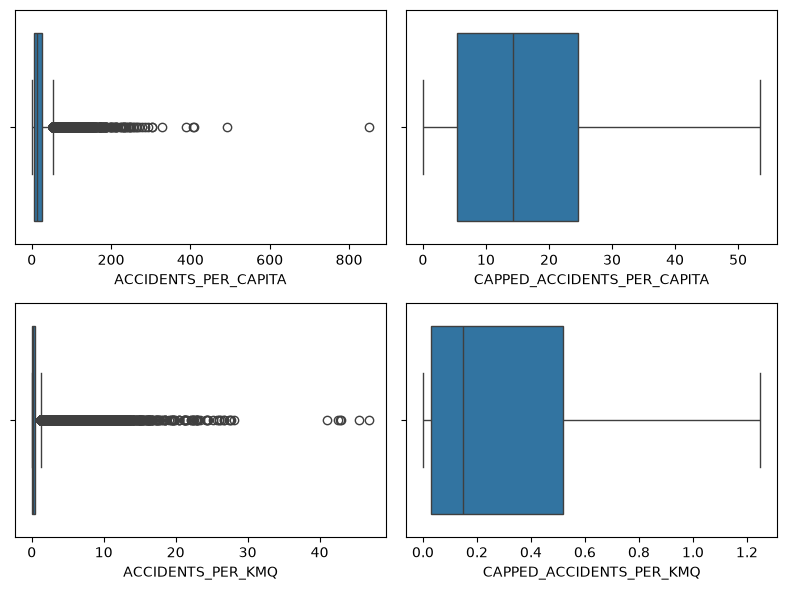

In [11]:
# Comparing original vs capped distributions for the two derived metrics using boxplot 
# Original columns show many outliers past the whiskers, capped columns don't
figure, axes = plt.subplots(2, 2, figsize=(8, 6))


sns.boxplot(x=df['ACCIDENTS_PER_CAPITA'], ax=axes[0, 0])
sns.boxplot(x=df['CAPPED_ACCIDENTS_PER_CAPITA'], ax=axes[0, 1])
sns.boxplot(x=df['ACCIDENTS_PER_KMQ'], ax=axes[1, 0])
sns.boxplot(x=df['CAPPED_ACCIDENTS_PER_KMQ'], ax=axes[1, 1])

plt.tight_layout()
plt.show()

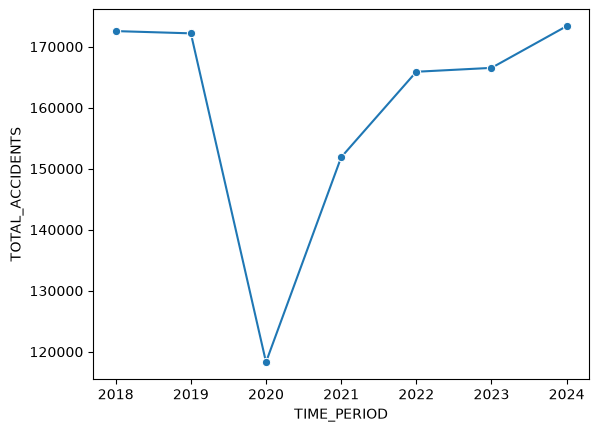

In [12]:
# Plotting accidents distribution through the years
# Data dropping at 2020 as expected 
total_acc_per_year = df.groupby('TIME_PERIOD')['TOTAL_ACCIDENTS'].sum().reset_index()
sns.lineplot(x='TIME_PERIOD', y='TOTAL_ACCIDENTS', data=total_acc_per_year , marker='o')
plt.show()

In [13]:
# Average ACCIDENTS_PER_CAPITA by province: North-Center provinces rank highest, South/Islands lowest
province_avg_acc_per_capita = df.groupby('PROVINCE_NAME')['ACCIDENTS_PER_CAPITA'].mean().sort_values(ascending=False)
print('Top 10 provinces by average ACCIDENTS_PER_CAPITA:')
print(province_avg_acc_per_capita.head(10))

print()

print('Bottom 10 provinces by average ACCIDENTS_PER_CAPITA:')
print(province_avg_acc_per_capita.tail(10))

Top 10 provinces by average ACCIDENTS_PER_CAPITA:
PROVINCE_NAME
Firenze         33.595156
Trieste         33.499597
Ravenna         33.253306
Savona          32.952251
Livorno         31.262073
Gorizia         28.726582
Pistoia         27.135256
Forlì-Cesena    26.671738
Piacenza        26.486451
Modena          25.710393
Name: ACCIDENTS_PER_CAPITA, dtype: float64

Bottom 10 provinces by average ACCIDENTS_PER_CAPITA:
PROVINCE_NAME
Foggia           9.703687
Vibo Valentia    9.570445
Crotone          9.555039
Campobasso       9.395741
Cosenza          9.182613
Caltanissetta    9.181755
Avellino         9.076463
Enna             8.937093
Agrigento        7.164239
Benevento        6.109468
Name: ACCIDENTS_PER_CAPITA, dtype: float64


In [14]:
# Average ACCIDENTS_PER_KMQ by province: dense metropolitan areas rank highest, rural/mountainous provinces lowest
province_avg_acc_per_kmq = df.groupby('PROVINCE_NAME')['ACCIDENTS_PER_KMQ'].mean().sort_values(ascending=False)
print('Top 10 provinces by average ACCIDENTS_PER_KMQ:')
print(province_avg_acc_per_kmq.head(10))

print()

print('Bottom 10 provinces by average ACCIDENTS_PER_KMQ:')
print(province_avg_acc_per_kmq.tail(10))

Top 10 provinces by average ACCIDENTS_PER_KMQ:
PROVINCE_NAME
Monza e della Brianza    4.336628
Milano                   3.957809
Napoli                   3.448656
Prato                    2.241810
Trieste                  2.091110
Rimini                   1.855194
Catania                  1.678797
Firenze                  1.575572
Varese                   1.403508
Pistoia                  1.372760
Name: ACCIDENTS_PER_KMQ, dtype: float64

Bottom 10 provinces by average ACCIDENTS_PER_KMQ:
PROVINCE_NAME
Enna            0.088349
Campobasso      0.087494
Foggia          0.082517
Matera          0.082503
Isernia         0.080512
L'Aquila        0.079812
Sud Sardegna    0.074251
Oristano        0.071850
Nuoro           0.071539
Potenza         0.064492
Name: ACCIDENTS_PER_KMQ, dtype: float64


In [ ]:
# Creating injured/killed per accident columns to investigate how serious accidents tend to be
df['INJURED_PER_ACCIDENT'] = df['INJURED'] / df['TOTAL_ACCIDENTS']
df['KILLED_PER_ACCIDENT'] = df['KILLED'] / df['TOTAL_ACCIDENTS']

df[['INJURED_PER_ACCIDENT', 'KILLED_PER_ACCIDENT']].describe()

,INJURED_PER_ACCIDENT,KILLED_PER_ACCIDENT
count,43405.000000,43405.000000
mean,1.457254,0.041365
std,0.570899,0.143661
min,0.000000,0.000000
25%,1.000000,0.000000
50%,1.347826,0.000000
75%,1.666667,0.006623
max,25.000000,5.000000


In [ ]:
# Rows with TOTAL_ACCIDENTS=0 become NaN and were automatically excluded by describe()
df['INJURED_PER_ACCIDENT'].isna().sum()

np.int64(10412)

In [21]:
# Investigating the extreme case of 25 injured per accident
# Most likley to be small number of total accidents with one severe multi-victim event (e.g. bus/van)
df.sort_values('INJURED_PER_ACCIDENT', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'TOTAL_ACCIDENTS', 'INJURED', 'INJURED_PER_ACCIDENT']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,TOTAL_ACCIDENTS,INJURED,INJURED_PER_ACCIDENT
1536,Salbertrand,Torino,2021,2,50,25.0
28432,Zeri,Massa-Carrara,2023,2,22,11.0
41479,Baragiano,Potenza,2024,4,42,10.5
33354,Villa Santa Lucia,Frosinone,2018,1,10,10.0
49611,Modolo,Oristano,2018,1,10,10.0
38652,Dogliola,Chieti,2018,1,10,10.0
39938,Panni,Foggia,2020,1,9,9.0
53267,Gesturi,Sud Sardegna,2020,1,9,9.0
39735,Biccari,Foggia,2019,1,9,9.0
3332,Barolo,Cuneo,2018,1,9,9.0


In [ ]:
# Investigating the extreme case of killed per accident
#Most of cases only show one accident, so a single fatal event influences the ratio
df.sort_values('KILLED_PER_ACCIDENT', ascending=False).head(10)[
    ['MUNICIPALITY', 'PROVINCE_NAME', 'TIME_PERIOD', 'TOTAL_ACCIDENTS', 'KILLED', 'KILLED_PER_ACCIDENT']]

,MUNICIPALITY,PROVINCE_NAME,TIME_PERIOD,TOTAL_ACCIDENTS,KILLED,KILLED_PER_ACCIDENT
3585,Castelmagno,Cuneo,2020,1,5,5.0
42796,Marzi,Cosenza,2022,1,3,3.0
51796,Spadola,Vibo Valentia,2019,1,3,3.0
19928,Bonavigo,Verona,2019,1,3,3.0
39674,Trivento,Campobasso,2018,1,3,3.0
25179,San Pietro in Cerro,Piacenza,2021,2,5,2.5
17755,Redondesco,Mantova,2019,1,2,2.0
7155,Lillianes,Valle d'Aosta/Vallée d'Aoste,2018,1,2,2.0
15355,Valvestino,Brescia,2020,1,2,2.0
38490,Ari,Chieti,2024,1,2,2.0
